# Display Test Accuracy

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [2]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 


                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
40    1
41    1
42    1
43    1
44    1
45    1
46    1
47    1
48    1
49    1
50    1
51    1
52    1
53    1
dtype: int64


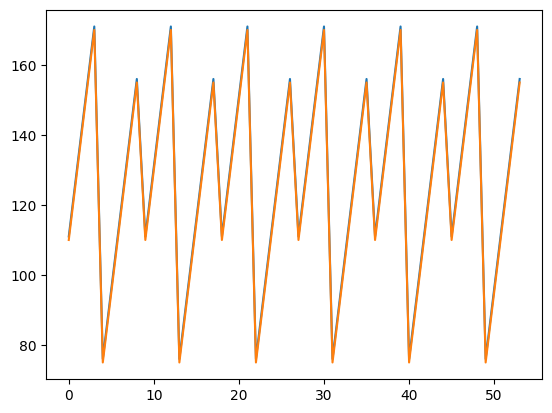

In [13]:
lrs=["5e-2", "1e-2"]

availabilities=availabilities="alphaF50-110sl-6cb-1ft alphaF50-130sl-6cb-1ft alphaF50-150sl-6cb-1ft alphaF50-170sl-6cb-1ft alphaF50-75sl-9cb-1ft alphaF50-95sl-9cb-1ft alphaF50-115sl-9cb-1ft alphaF50-135sl-9cb-1ft alphaF50-155sl-9cb-1ft".split()

main_folder = 'correlation_experiments_100rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_debug", seeds=["42", "78", "84"],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=lrs, alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")


results_df = get_exp_stats(config)

results_df["n_rounds"] = results_df["test_accuracy"].apply(lambda x: len(x))

results_df

targets = results_df["availability"].apply(lambda x: int(x.split("-")[1].replace("sl", "")))
values = results_df["n_rounds"].apply(lambda x: int(x))

plt.plot(values)
plt.plot(targets)

print(values - targets)

In [ ]:
# rest="alphaF50-11sl-10cb-3ft alphaF50-12sl-10cb-3ft alphaF50-13sl-10cb-3ft alphaF50-14sl-10cb-3ft alphaF50-15sl-10cb-3ft alphaF50-25sl-10cb-3ft alphaF50-35sl-10cb-3ft alphaF50-45sl-10cb-3ft alphaF50-5sl-11cb-3ft alphaF50-6sl-11cb-3ft alphaF50-7sl-11cb-3ft ".split()
# len(rest)

# # alphaF50-8sl-11cb-3ft alphaF50-9sl-11cb-3ft alphaF50-10sl-11cb-3ft alphaF50-11sl-11cb-3ft alphaF50-12sl-11cb-3ft alphaF50-13sl-11cb-3ft alphaF50-14sl-11cb-3ft alphaF50-24sl-11cb-3ft alphaF50-34sl-11cb-3ft alphaF50-44sl-11cb-3ft

11

In [ ]:
tmp = results_df.groupby(['availability','lr']).test_accuracy.apply(np.vstack).to_frame().reset_index()

In [ ]:
tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
tmp['mean_var_test_acc'] = tmp['var_test_acc'].apply(lambda x : x.mean())
tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))

,algorithm,availability,lr,mean_var_test_acc
0,fedavg,alphaF50-33sl-4cb-3ft,1e-2,0.0
1,fedavg,alphaF50-33sl-4cb-3ft,5e-2,0.0


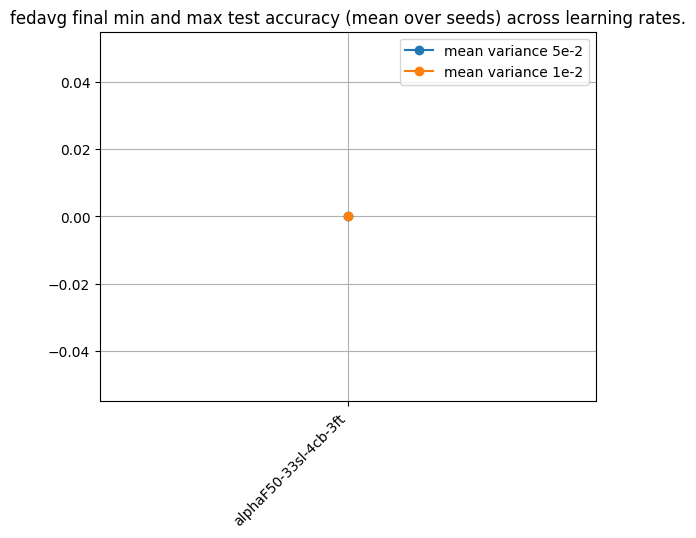

In [ ]:
tmp_lr = tmp[['availability', 'lr', 'mean_var_test_acc']]
display(tmp_lr)

x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr==lrs[0]),'availability']]
for algo in ['fedavg']:
    plt.figure()

    for lr in lrs:
        plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)]['mean_var_test_acc'], '-o', label='mean variance '+lr)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.title(algo+' final min and max test accuracy (mean over seeds) across learning rates.')
    plt.grid()

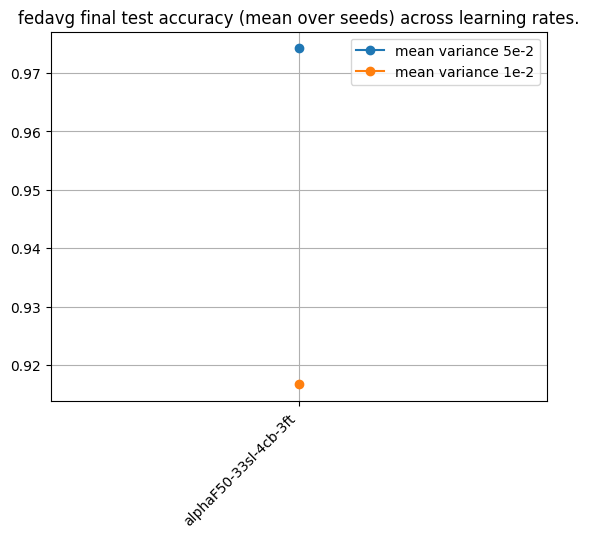

In [ ]:
tmp_lr = tmp[['availability', 'lr', 'final_mean_acc']]

x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr==lrs[0]),'availability']]
for algo in ['fedavg']:
    plt.figure()

    for lr in lrs:
        plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)]['final_mean_acc'], '-o', label='mean variance '+lr)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.title(algo+' final test accuracy (mean over seeds) across learning rates.')
    plt.grid()

In [ ]:
res_old = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()]

In [ ]:
max_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'max_final_mean_acc'})
min_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmin()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'min_final_mean_acc'})

In [ ]:
res_ = pd.merge(max_res, min_res, on=['algorithm', 'availability'], how='outer')

In [ ]:
res_

,algorithm,availability,max_final_mean_acc,min_final_mean_acc
0,fedavg,alphaF50-33sl-4cb-3ft,0.9742,0.9167


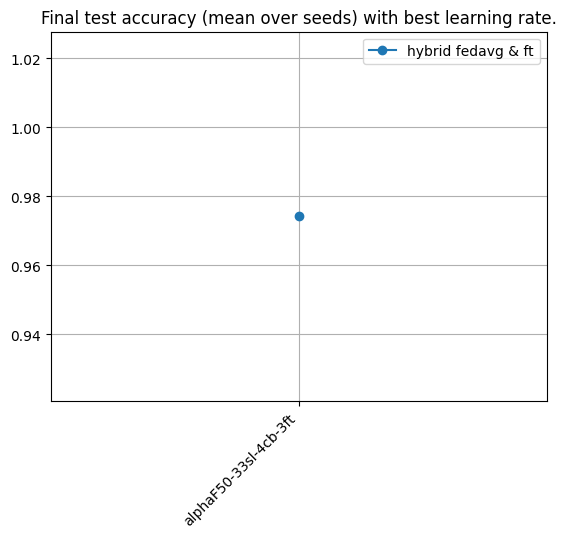

In [ ]:
x_values = [a.replace('gp-','').replace('-10ft', '') for a in res_[res_.algorithm=='fedavg']['availability']]

plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='hybrid fedavg & ft')
# plt.plot(x_values, res_[res_.algorithm=='fedvarp']['max_final_mean_acc'], '-o', label='hybrid fedvarp & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Final test accuracy (mean over seeds) with best learning rate.')
plt.grid()

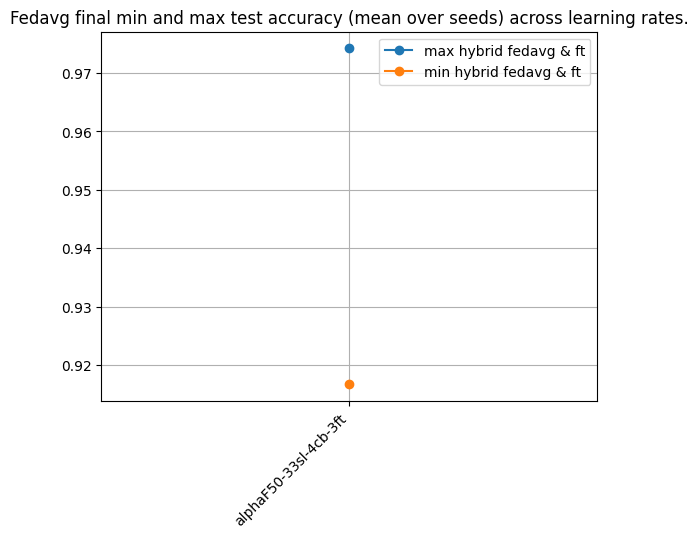

In [ ]:
plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='max hybrid fedavg & ft')
plt.plot(x_values, res_[res_.algorithm=='fedavg']['min_final_mean_acc'], '-o', label='min hybrid fedavg & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Fedavg final min and max test accuracy (mean over seeds) across learning rates.')
plt.grid()